        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25    172.0       1092.00    122.0       1583.75      1203.25   
4         835.50    131.0       1205.00    116.0       1490.00      1110.00   

       T         RH        AH  
0  13.60  48.875001  0.757754  
1  13.30  47.700000  0.725487  
2  11.90  53.975000 

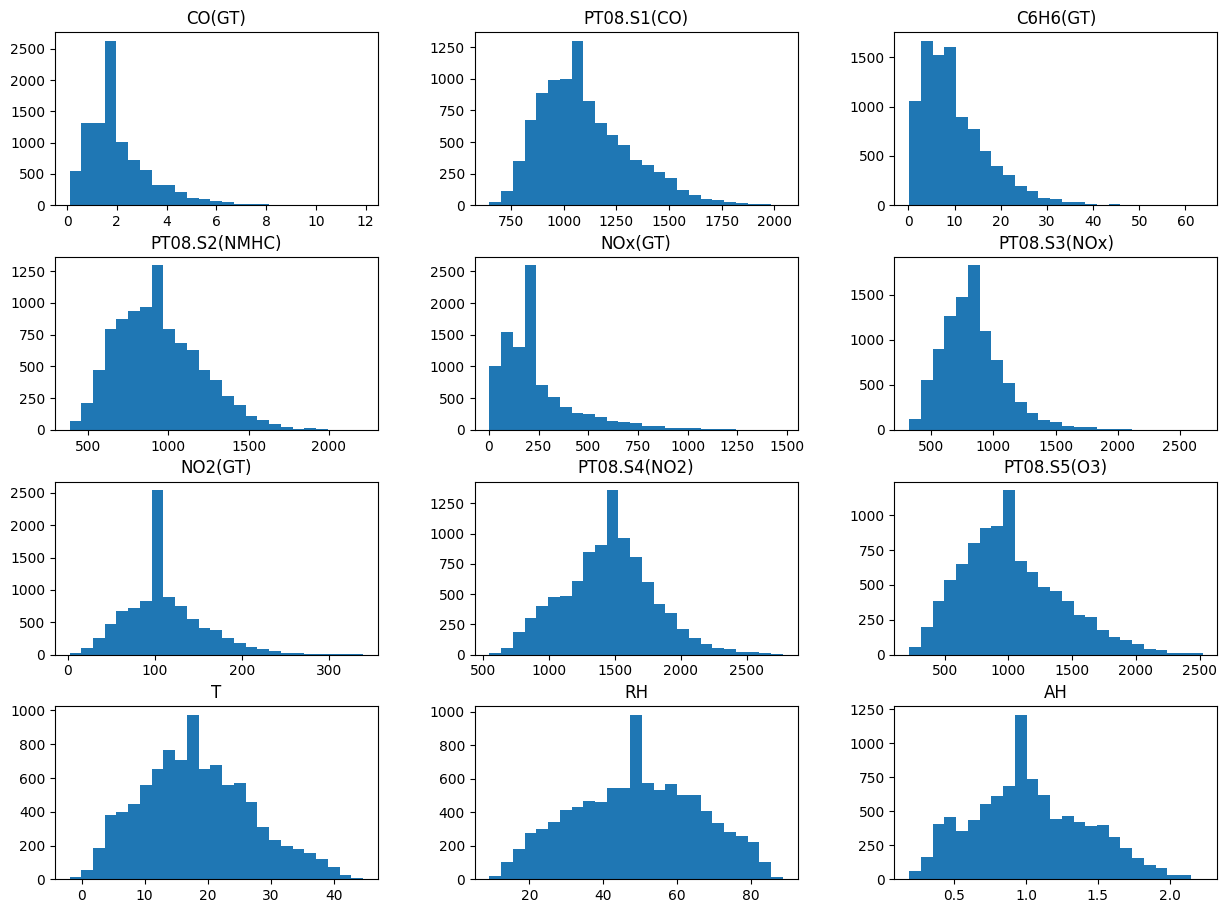

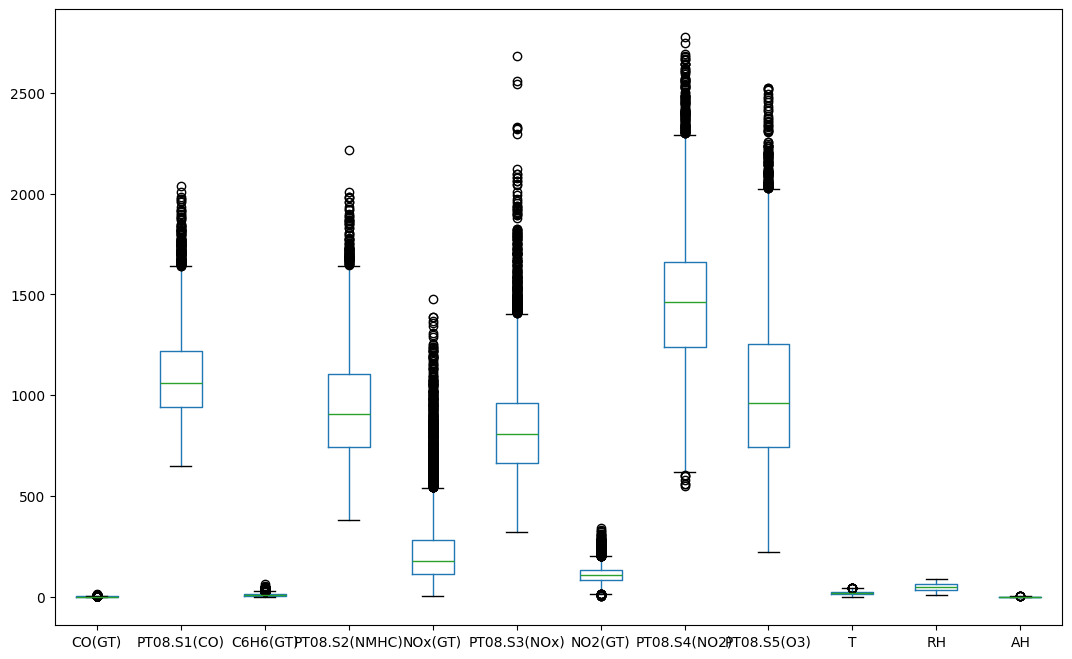

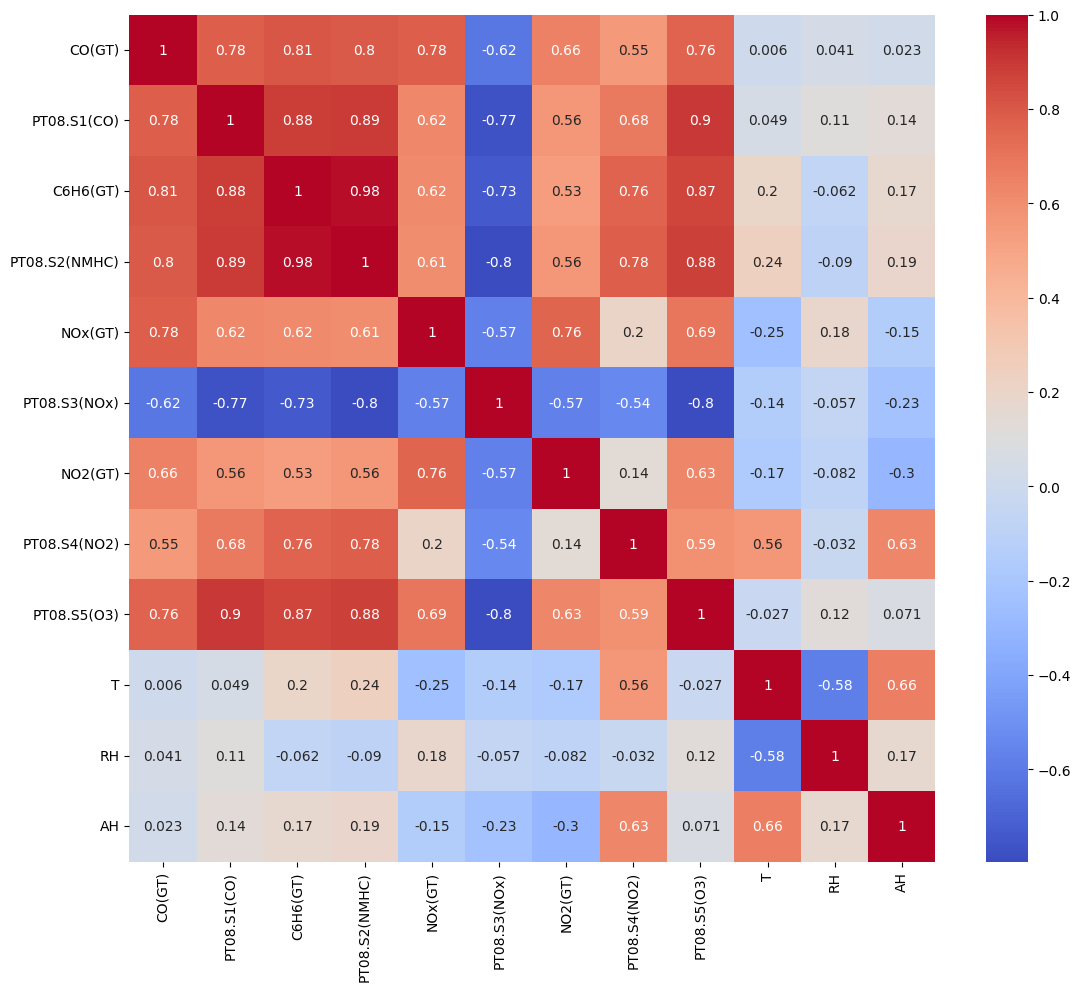

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import RobustScaler
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Load data
df = pd.read_excel('AirQualityUCI.xlsx')

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum().sort_values(ascending=False))

# Treat missing values
df = df.replace(-200, np.nan)
df = df.drop(['NMHC(GT)'], axis=1)
df = df.fillna(df.median(numeric_only=True))

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum().sort_values(ascending=False))

# Visualize the data
df.drop(['Date'], axis=1).hist(bins=25, figsize=(15,11), grid=False)
plt.show()

df.drop(['Date'], axis=1).boxplot(figsize=(13,8), grid=False)
plt.show()

# Correlation with the target
plt.figure(figsize=(13,11))
sns.heatmap(df.drop(['Date','Time'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()


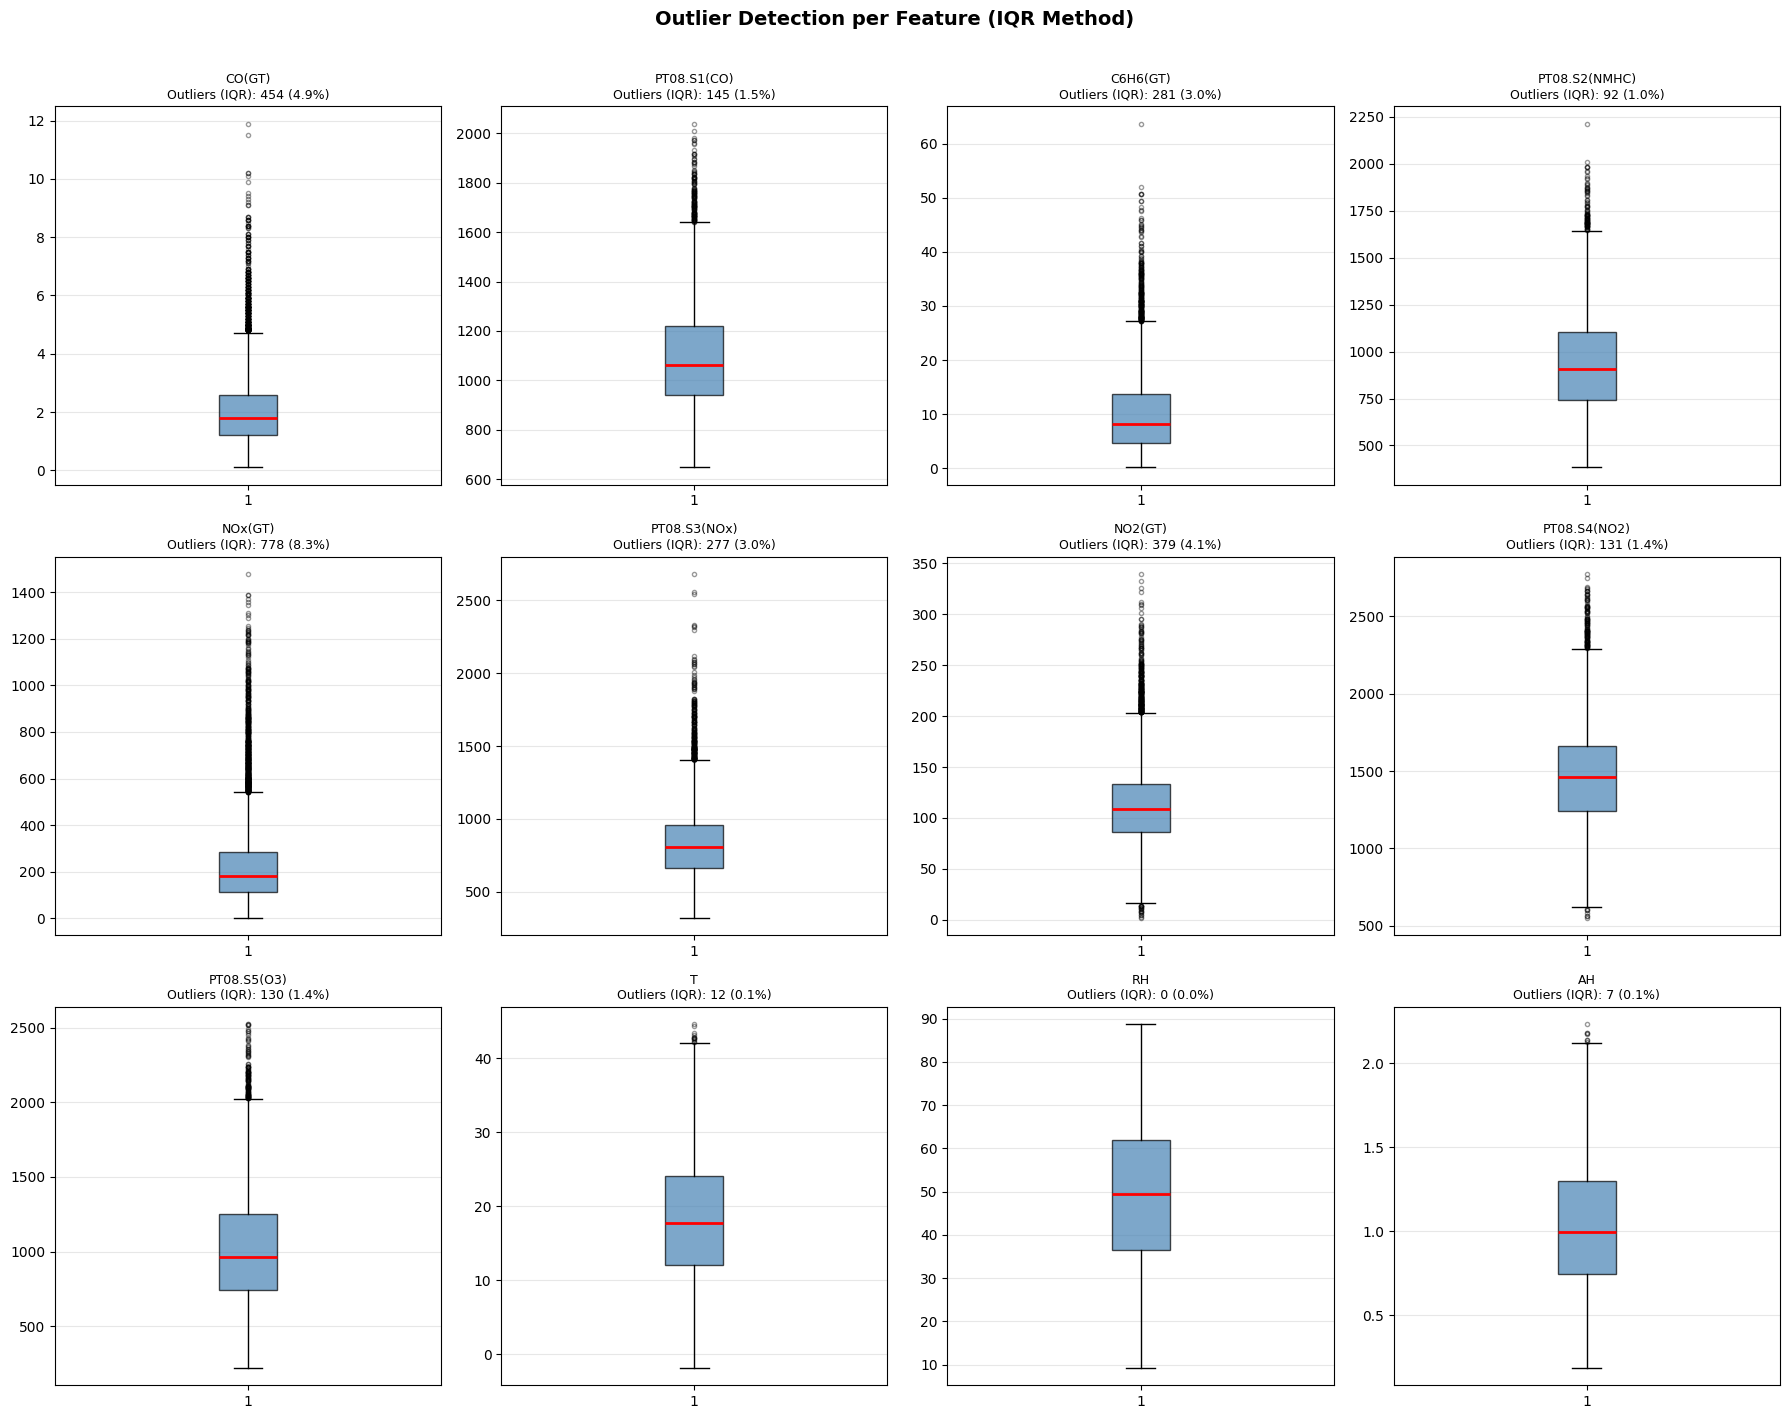

In [6]:
# Check outliers percentage
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    outlier_summary.append({
        'Column': col, 'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
        'IQR': round(IQR, 3), 'Lower Bound': round(lower, 3),
        'Upper Bound': round(upper, 3), 'N Outliers': n_outliers, '% Outliers': round(pct, 2)
    })

iqr_df = pd.DataFrame(outlier_summary)

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='tomato', alpha=0.4, markersize=3))
    axes[i].set_title(f'{col}\nOutliers (IQR): {n_out} ({n_out/len(df)*100:.1f}%)', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection per Feature (IQR Method)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
'''
# Just for comparison 
# Control the skewness
from scipy.stats.mstats import winsorize

# Skewness with masive outliers
cols_log = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
for masive in cols_log:
    df[masive] = np.log1p(df[masive].clip(lower=0))

# Medium skewness
cols_wins = ['PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
for col in cols_wins:
    df[col] = winsorize(df[col], limits=[0.01, 0.05])
'''

# Split data
x = df.drop(['Date', 'Time', 'CO(GT)'], axis=1)
y = df['CO(GT)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Models
models = {
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(random_state=42),
    'Cat Boost Regressor': CatBoostRegressor(verbose=0),
    'Linear Regression': LinearRegression(),
}
results = []
pipelines = {}
for name, method in models.items():
    main_pipeline = Pipeline([
        ('preprocessing', RobustScaler()),
        ('models', method),
    ])
    main_pipeline.fit(x_train, y_train)
    predict = main_pipeline.predict(x_test)
    pipelines[name] = main_pipeline  
    results.append({
        'Model': name,
        'R2 Score': r2_score(y_test, predict),
        'MAE': mean_absolute_error(y_test, predict),

    })

# Evaluate Result
evaluate = pd.DataFrame(results)

result_table = evaluate[['Model', 'MAE', 'R2 Score']].copy()
result_table.columns = ['Model', 'MAE', 'R2']

# Format numbers
result_table['MAE'] = result_table['MAE'].map(lambda x: f"{x:.4f}")
result_table['R2'] = result_table['R2'].map(lambda x: f"{x:.4f}")

# Print tabel
print(result_table.to_markdown())

|    | Model                   |    MAE |     R2 |
|---:|:------------------------|-------:|-------:|
|  0 | Random Forest Regressor | 0.2933 | 0.8867 |
|  1 | Hist Gradient Boosting  | 0.3037 | 0.8834 |
|  2 | Cat Boost Regressor     | 0.2913 | 0.8923 |
|  3 | Linear Regression       | 0.3823 | 0.827  |


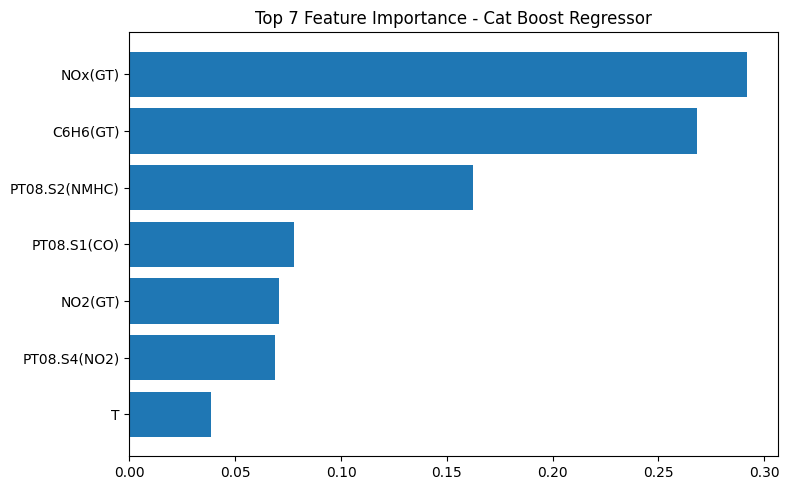

In [8]:
# Top 7 Feature Importance - Cat Boost Regressor
from sklearn.inspection import permutation_importance

perm = permutation_importance(pipelines['Cat Boost Regressor'], x_test, y_test, n_repeats=10, random_state=42)

fi_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False).head(7)

plt.figure(figsize=(8, 5))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1])
plt.title('Top 7 Feature Importance - Cat Boost Regressor')
plt.tight_layout()
plt.show()